# 🔢 MNIST Digit Recognizer

## 0. Introduction

### 0.1 Overview
The MNIST data can be used to learn computer vision fundamentals and deep learning foundations. Such foundations will be presented in this notebook by **exploring the performance of a MLP and CNN on this famous dataset.**

### 🎯 0.2 Objectives
* Create a deep MLP Model
* Create a CNN Model
* Optimize different hyperparamters for both types of models 
* Pick the best model and observe its performance on the data.
* Sample predictions: Present its capabilities on samples of the data

### 0.3 Project Context

MNIST ("Modified National Institute of Standards and Technology") dataset contains imagery of handwritten digits and is a well-known dataset for practicing classification and computer vision. In fact it is known as "the de facto “hello world” dataset of computer vision."

Project Source: [Dataset from Kaggle](https://www.kaggle.com/competitions/digit-recognizer)

### 0.4 Key Findings
* From classification with Logistic Regression to Deep Learning, neural networks display an advantageous gap in performance.
* Tuning hyperparamaters was always beneficial for the neural networks.
* Final validation scores are:
    1. **Tuned CNN            - 0.9924**
    2. Base CNN             - 0.9885
    3. Tuned MLP            - 0.9776
    4. Base MLP             - 0.9744
    5. Log Regression       - 0.9146
* 🏆️ The best model is a tuned CNN model.

### 0.5 Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from lightning.pytorch.utilities.model_summary import ModelSummary
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from pytorch_lightning.loggers import CSVLogger
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.optim import SGD, Adam, AdamW, RMSprop
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, StepLR
from torch.utils.data import DataLoader, TensorDataset

pl.seed_everything(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_palette(["lightseagreen", "darkorange"])


print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {pl.__version__}")

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


PyTorch: 2.11.0+cu130
Lightning: 2.6.1
GPU Available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## 1. Data Preparation

### 1.0 Splitting Data

Note: each pixel is 0-255, we squish it to 0-1 by diving by 255 `/ 255.0`. Neural networks train much better on small numbers

In [2]:
df = pd.read_csv("dataset/train.csv")
print(f"Raw dataset shape: {df.shape}")

X = df.drop("label", axis=1).values.astype(np.float32) / 255.0
y = df["label"].values.astype(np.int64)

Raw dataset shape: (42000, 785)


#### Splitting the data (60 / 20 / 20)
Considering that hypertuning will be performed, a validation set will be useful:
* Train set: 60%
* Validation set: 20%
* Test set: 20%

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for name, arr in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
    print(f"{name}: {arr.shape[0]} samples ({arr.shape[0]/len(X)*100:.1f}%)")

Train: 25200 samples (60.0%)
Val: 8400 samples (20.0%)
Test: 8400 samples (20.0%)


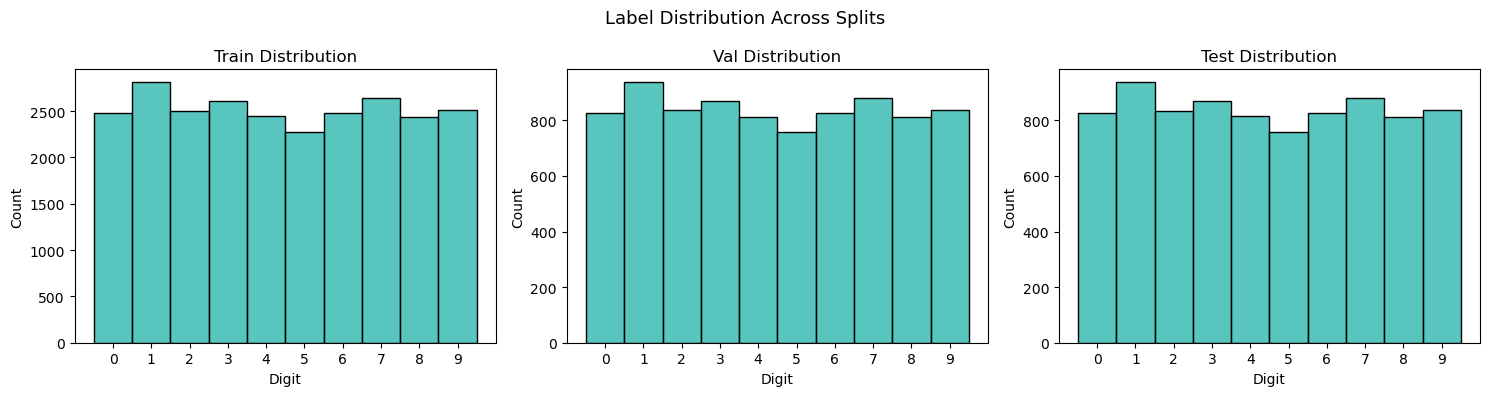

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (split_name, split_y) in zip(
    axes, [("Train", y_train), ("Val", y_val), ("Test", y_test)]
):
    sns.histplot(split_y, bins=10, ax=ax, discrete=True)
    ax.set_title(f"{split_name} Distribution")
    ax.set_xlabel("Digit")
    ax.set_ylabel("Count")
    ax.set_xticks(range(10))

plt.suptitle("Label Distribution Across Splits", fontsize=13)
plt.tight_layout()
plt.show()

### 1.1 Data Integrity Checks

#### 1.1.1 Null or Duplicate values:

In [5]:
for split_name, split_X, split_y in [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test),
]:
    df_split = pd.DataFrame(split_X)
    nulls = df_split.isnull().sum().sum()
    duplicates = df_split.duplicated().sum()
    print(f"{split_name} nulls: {nulls} | Duplicates: {duplicates}")

Train nulls: 0 | Duplicates: 0
Val nulls: 0 | Duplicates: 0
Test nulls: 0 | Duplicates: 0


✅ No nulls or duplicates across the sets

#### 1.1.2 Invalid data:
Possible edge cases to check:
* Pixels out of range
* All black pixels
* All white pixels
* Images with only one unique pixel value

In [6]:
out_of_range = ((X_train < 0) | (X_train > 1)).sum()
print(f"Pixels out of range [0,1]: {out_of_range}")

all_black = (X_train.sum(axis=1) == 0).sum()
print(f"All black images: {all_black}")

all_white = (X_train.sum(axis=1) == 784).sum()
print(f"All white images: {all_white}")

single_value = np.array([len(np.unique(row)) == 1 for row in X_train]).sum()
print(f"Single value images: {single_value}")

Pixels out of range [0,1]: 0
All black images: 0
All white images: 0
Single value images: 0


### 📊 1.2 Data Overview / EDA

In [7]:
df_train = pd.DataFrame(X_train)
print(df_train.shape)

(25200, 784)


In [8]:
print(df_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 25200 entries, 0 to 25199
Columns: 784 entries, 0 to 783
dtypes: float32(784)
memory usage: 75.4 MB
None


In [9]:
print(df_train.describe())

           0        1        2        3        4        5        6        7    \
count  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0  25200.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

           8        9    ...           774           775           776  \
count  25200.0  25200.0  ...  25200.000000  25200.000000  25200.000000   
mean       0.0      0.0  ...      0.000880      0.000471      0.000199   
std        0.0      0.0  ...      0.025797      

Data is presented in pixel values and each of the 784 columns is one pixel. Presence of a number indicates pixels, and its value tells us how bright the pixel is. 

In [10]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

Data is presented in pixel values as above, and presents as below:

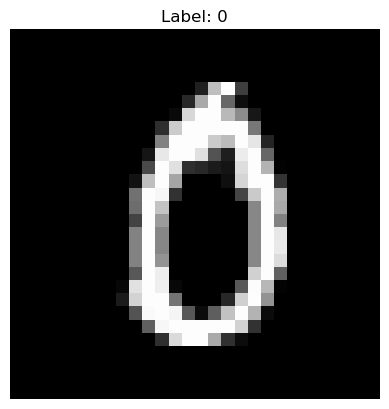

In [11]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

## 2. Model Building

### 2.0 Logistic Regression

Baseline model

In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"Logistic Regression val_acc : {lr.score(X_val, y_val):.4f}")
scores = {}
scores["Log Regression"] = round(lr.score(X_val, y_val), 4)

Logistic Regression val_acc : 0.9137


Starting with **0.91** as our performance baseline for neural networks

### 2.1 Multilayer Perceptron Model (MLP)
1. Base MLP
2. Tuned MLP

DataModule and DataLoaders

Utilize a DataModule with Lightning to handle calling dataloaders

In [13]:
class DigitDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=256):
        super().__init__()
        self.batch_size = batch_size

    def _ds(self, X, y):
        return TensorDataset(torch.tensor(X), torch.tensor(y))

    def train_dataloader(self):
        return DataLoader(
            self._ds(X_train, y_train), batch_size=self.batch_size, shuffle=True
        )

    def val_dataloader(self):
        return DataLoader(self._ds(X_val, y_val), batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self._ds(X_test, y_test), batch_size=self.batch_size)

In [14]:
dm = DigitDataModule(batch_size=256)
x_batch, y_batch = next(iter(dm.train_dataloader()))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")

Batch X shape: torch.Size([256, 784])
Batch y shape: torch.Size([256])


#### 2.1.1 Base MLP

Initializing the model class 

In [15]:
class MLPClassifier(pl.LightningModule):
    def __init__(
        self,
        hidden_layers=[512, 256, 128],
        activation="relu",
        dropout=0.3,
        optimizer="adam",
        lr=1e-3,
        loss_fn="cross_entropy",
    ):
        super().__init__()
        self.save_hyperparameters()

        acts = {"relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU, "tanh": nn.Tanh}
        loss_fns = {
            "cross_entropy": nn.CrossEntropyLoss(),
            "label_smoothing": nn.CrossEntropyLoss(label_smoothing=0.1),
        }
        self.loss_fn = loss_fns[loss_fn]

        layers, in_dim = [], 784
        for h in hidden_layers:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                acts[activation](),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{stage}_acc", acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        return self._step(batch, "val")

    def test_step(self, batch, _):
        return self._step(batch, "test")

    def configure_optimizers(self):
        opts = {"adam": Adam, "adamw": AdamW, "sgd": SGD, "rmsprop": RMSprop}
        extra = {"momentum": 0.9} if self.hparams.optimizer == "sgd" else {}
        return opts[self.hparams.optimizer](
            self.parameters(), lr=self.hparams.lr, **extra
        )

Run Basic

Training loop with default simple hyperparameters, early stopping

In [16]:
def run(config, epochs=10, progress=False, log=False, name="mlp"):
    dm = DigitDataModule(batch_size=config.get("batch_size", 256))
    model = MLPClassifier(**{k: v for k, v in config.items() if k != "batch_size"})

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, verbose=False, mode="min"),
    ]

    if log:
        callbacks += [
            ModelCheckpoint(
                monitor="val_acc",
                mode="max",
                dirpath="checkpoints",
                filename="best-{epoch:02d}-{val_acc:.4f}",
                save_top_k=1,
            ),
            LearningRateMonitor(logging_interval="epoch"),
        ]

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        callbacks=callbacks,
        enable_progress_bar=progress,
        logger=CSVLogger("logs", name=name) if log else False,
    )

    trainer.fit(model, dm)
    return trainer, model, dm

In [17]:
baseline_config = {
    "hidden_layers": [128],
    "activation": "relu",
    "optimizer": "adam",
    "lr": 1e-3,
    "dropout": 0.0,
    "loss_fn": "cross_entropy",
    "batch_size": 32,
}

trainer, model, dm = run(
    baseline_config, epochs=50, progress=True, log=True, name="base_mlp"
)
base_mlp_log_dir = trainer.logger.log_dir
base_mlp_score = float(trainer.callback_metrics["val_acc"])
print("Baseline val_acc:", round(base_mlp_score, 4))
scores["Base MLP"] = round(base_mlp_score, 4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/linuxg/Desktop/Turing/Unsupervised/fundamentals-project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ net     │ Sequential       │  102 K │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connect
or.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value
of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connect
or.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

Baseline val_acc: 0.9698


#### 2.1.2 Tuned MLP

> Make sure to test different optimizers, batch sizes, activation functions, learning rates, dropout ratios, hidden layer architectures, loss functions.

Hypertuning was performed on the data. To save time, the best params were saved into a dictionary, `best_params` found below, and called instead of running the Optuna function and trials again.

In [19]:
def objective(trial, model_type="mlp"):
    if model_type == "mlp":
        config = {
            "hidden_layers": trial.suggest_categorical(
                "hidden_layers",
                [
                    [256, 128],
                    [512, 256, 128],
                    [1024, 512, 256],
                    [512, 256, 128, 64],
                ],
            ),
            "activation": trial.suggest_categorical(
                "activation", ["relu", "gelu", "silu", "tanh"]
            ),
            "optimizer": trial.suggest_categorical(
                "optimizer", ["adam", "adamw", "sgd", "rmsprop"]
            ),
            "lr": trial.suggest_float("lr", 1e-4, 1e-1, log=True),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "loss_fn": trial.suggest_categorical(
                "loss_fn", ["cross_entropy", "label_smoothing"]
            ),
            "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        }
        trainer, _, _ = run(config, epochs=10)

    elif model_type == "cnn":
        config = {
            "out_channels": trial.suggest_categorical(
                "out_channels",
                [
                    [32, 64],
                    [64, 128],
                    [32, 64, 128],
                    [64, 128, 256],
                ],
            ),
            "lr": trial.suggest_float("lr", 1e-4, 1e-1, log=True),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        }
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
        dm = DigitDataModule(batch_size=batch_size)
        model = CNNClassifier(**config)
        trainer = pl.Trainer(
            max_epochs=10,
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            callbacks=[EarlyStopping(monitor="val_loss", patience=3)],
            enable_progress_bar=False,
            logger=False,
        )
        trainer.fit(model, dm)

    return float(trainer.callback_metrics.get("val_acc", 0))

In [20]:
# mlp_study = optuna.create_study(direction="maximize")
# mlp_study.optimize(
#     lambda trial: objective(trial, model_type="mlp"),
#     n_trials=20,
#     show_progress_bar=True,
# )
# print("MLP best val_acc:", mlp_study.best_value)
# print("MLP best params: ", mlp_study.best_params)

*Direct results from the above code:*


* *Best val_acc: 0.9776190519332886*
* *Best params:  {'hidden_layers': [512, 256, 128], 'activation': 'gelu', 'optimizer': 'adam', 'lr': 0.0005098266493777777, 'dropout': 0.1769574139159608, 'loss_fn': 'label_smoothing', 'batch_size': 128}*

In [21]:
best_params = {
    "hidden_layers": [512, 256, 128],
    "activation": "gelu",
    "optimizer": "adam",
    "lr": 0.0005098266493777777,
    "dropout": 0.1769574139159608,
    "loss_fn": "label_smoothing",
    "batch_size": 128,
}

In [22]:
best_config = best_params
best_config["hidden_layers"] = (
    eval(best_config["hidden_layers"])
    if isinstance(best_config["hidden_layers"], str)
    else best_config["hidden_layers"]
)

trainer, model, dm = run(
    best_config, epochs=50, progress=True, log=True, name="tuned_mlp"
)
tuned_mlp_log_dir = trainer.logger.log_dir
scores["Tuned MLP"] = round(float(trainer.callback_metrics["val_acc"]), 4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ net     │ Sequential       │  569 K │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 569 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 569 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training Curves: Base vs. Tuned

In [ ]:
def plot_csv_logger(csv_path, model_name):
    import os

    metrics = pd.read_csv(csv_path)

    aggreg_metrics = []
    for i, dfg in metrics.groupby("epoch"):
        agg = dict(dfg.mean())
        agg["epoch"] = i
        aggreg_metrics.append(agg)

    df = pd.DataFrame(aggreg_metrics)
    os.makedirs("images", exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for col in ["train_loss", "val_loss"]:
        if col in df:
            axes[0].plot(df["epoch"], df[col], label=col)
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True)

    for col in ["train_acc", "val_acc"]:
        if col in df:
            axes[1].plot(df["epoch"], df[col], label=col)
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig(f"images/{model_name}_curves.png")
    plt.show()

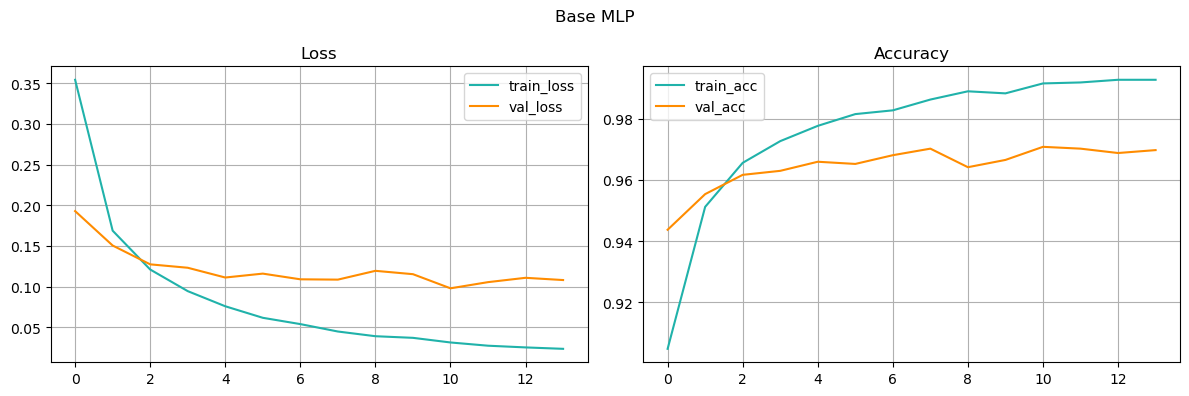

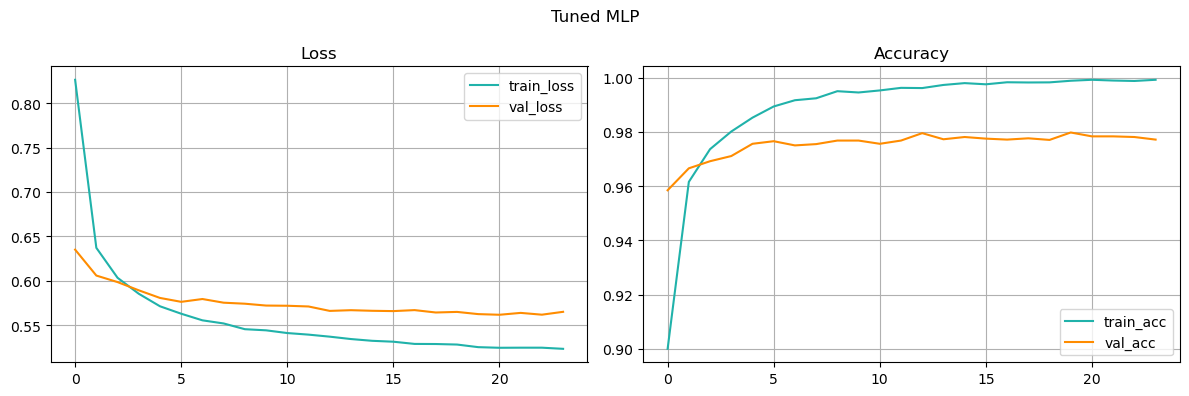

In [23]:
plot_csv_logger(f"{base_mlp_log_dir}/metrics.csv", "Base MLP")
plot_csv_logger(f"{tuned_mlp_log_dir}/metrics.csv", "Tuned MLP")

### 2.2 CNN Model
#### 2.2.1 Base CNN

In [24]:
class CNNClassifier(pl.LightningModule):
    def __init__(self, out_channels=[32, 64], lr=1e-3, dropout=0.3):
        super().__init__()
        self.save_hyperparameters()

        cnn_layers = []
        in_channels = 1
        for out_channel in out_channels:
            cnn_layers += [
                nn.Conv2d(in_channels, out_channel, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channel),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
            ]
            in_channels = out_channel
        self.cnn_layers = nn.Sequential(*cnn_layers)

        dummy = torch.zeros(1, 1, 28, 28)
        flat_size = self.cnn_layers(dummy).view(1, -1).shape[1]

        self.fc_layers = nn.Sequential(
            nn.Linear(flat_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.cnn_layers(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc_layers(x)

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        acc_metric = {
            "train": self.train_acc,
            "val": self.val_acc,
            "test": self.test_acc,
        }[stage]
        acc_metric(preds, y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(
            f"{stage}_acc", acc_metric, prog_bar=True, on_epoch=True, on_step=False
        )
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        return self._step(batch, "val")

    def test_step(self, batch, _):
        return self._step(batch, "test")

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.hparams.lr)

Running CNN Model

In [25]:
cnn_model = CNNClassifier(out_channels=[32, 64], lr=1e-3)
cnn_trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3)],
    logger=CSVLogger("logs", name="cnn_base"),
    enable_progress_bar=True,
)
dm = DigitDataModule(batch_size=256)
cnn_trainer.fit(cnn_model, dm)
base_cnn_log_dir = trainer.logger.log_dir
cnn_results = cnn_trainer.validate(cnn_model, dm)
print(f"Base CNN val_acc : {round(cnn_results[0]['val_acc'], 4)}")
scores["Base CNN"] = round(cnn_results[0]["val_acc"], 4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cnn_layers │ Sequential         │ 19.0 K │ train │     0 │
│ 1 │ fc_layers  │ Sequential         │  403 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 422 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 422 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9883333444595337     │
│         val_loss          │   0.039082594215869904    │
└───────────────────────────┴───────────────────────────┘

Base CNN val_acc : 0.9883


#### 2.2.2 Tuned CNN

Similar to the MLP tuning, CNN tuning was conducted earlier and the results were saved into `best_cnn_params`.

In [26]:
# cnn_study = optuna.create_study(direction="maximize")
# cnn_study.optimize(
#     lambda trial: objective(trial, model_type="cnn"),
#     n_trials=20,
#     show_progress_bar=True,
# )
# print("CNN best val_acc:", cnn_study.best_value)
# print("CNN best params: ", cnn_study.best_params)

*Direct results from the tuner code above:*
* *Best val_acc: 0.9923809766769409*
* *Best params:  {'out_channels': [64, 128, 256], 'lr': 0.00048494250581998467, 'batch_size': 512}*

In [27]:
best_cnn_params = {
    "out_channels": [64, 128, 256],
    "lr": 0.00048494250581998467,
    "batch_size": 512,
}

In [28]:
best_cnn_params["out_channels"] = (
    eval(best_cnn_params["out_channels"])
    if isinstance(best_cnn_params["out_channels"], str)
    else best_cnn_params["out_channels"]
)

dm = DigitDataModule(batch_size=best_cnn_params["batch_size"])
cnn_model = CNNClassifier(
    out_channels=best_cnn_params["out_channels"], lr=best_cnn_params["lr"]
)

cnn_trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5)],
    logger=CSVLogger("logs", name="cnn_tuned"),
    enable_progress_bar=True,
)
cnn_trainer.fit(cnn_model, dm)
tuned_cnn_log_dir = trainer.logger.log_dir
cnn_results = cnn_trainer.validate(cnn_model, dm)
scores["Tuned CNN"] = round(cnn_results[0]["val_acc"], 4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cnn_layers │ Sequential         │  370 K │ train │     0 │
│ 1 │ fc_layers  │ Sequential         │  296 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 667 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 667 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9919047355651855     │
│         val_loss          │   0.028473831713199615    │
└───────────────────────────┴───────────────────────────┘

Tuned Training Curve

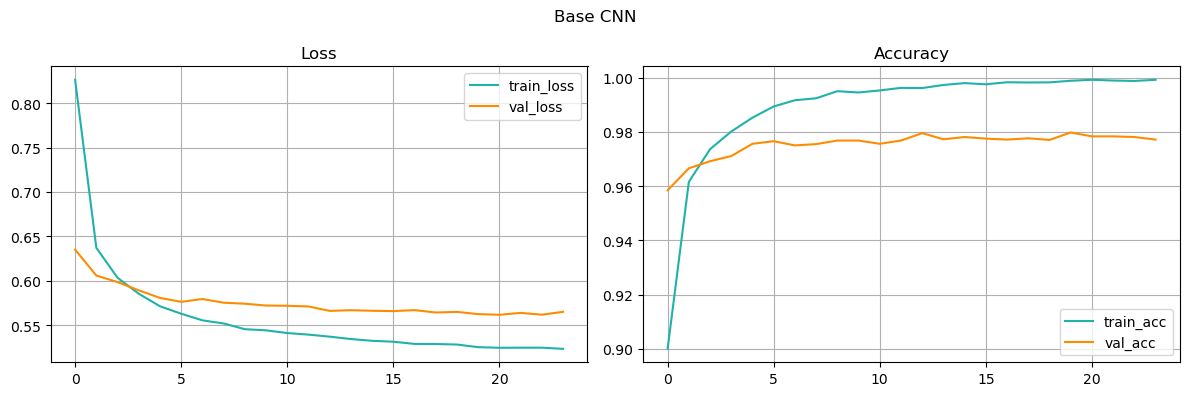

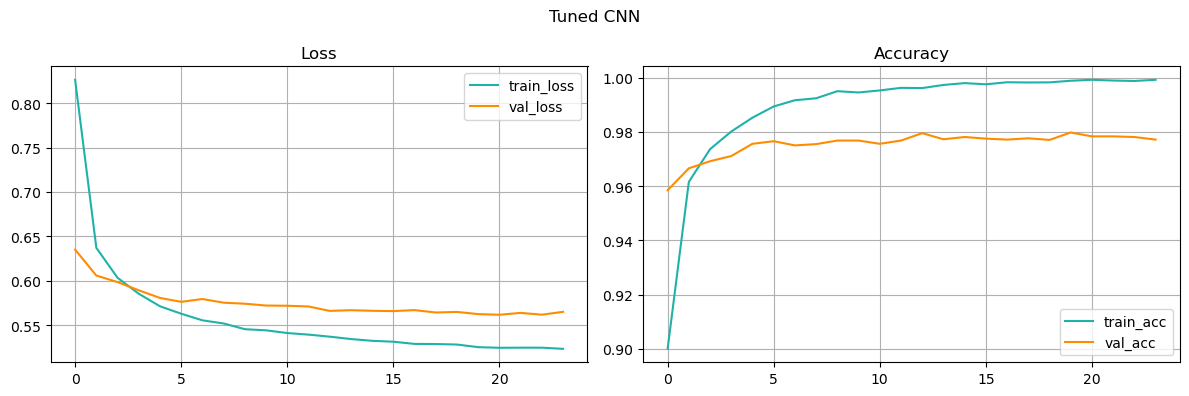

In [29]:
plot_csv_logger(f"{base_cnn_log_dir}/metrics.csv", "Base CNN")
plot_csv_logger(f"{tuned_cnn_log_dir}/metrics.csv", "Tuned CNN")

## 🏆️ 3. Model Results

### 3.1 All Models Comparison

In [30]:
for model, acc in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {acc:.4f}")

Tuned CNN                 0.9919
Base CNN                  0.9883
Tuned MLP                 0.9771
Base MLP                  0.9698
Log Regression            0.9146


/tmp/ipykernel_218317/3154246594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


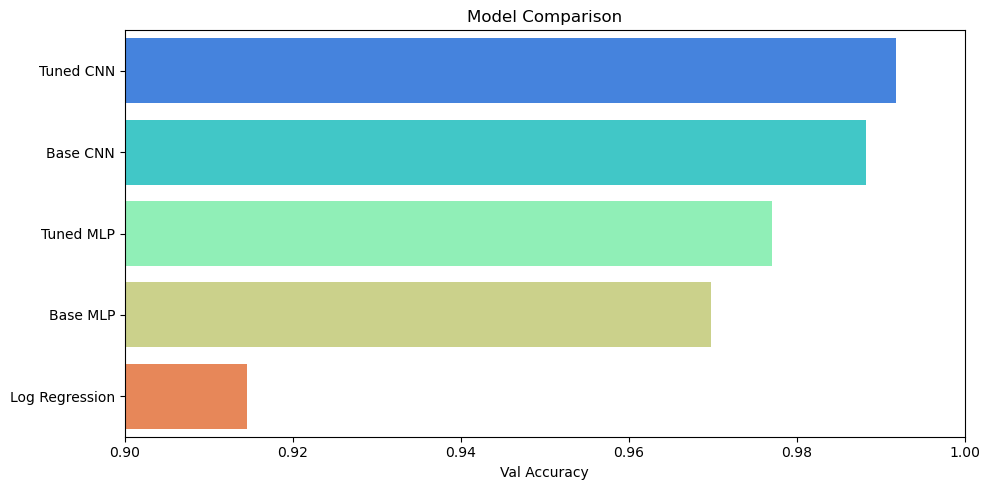

In [31]:
sorted_scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(sorted_scores.values()),
    y=list(sorted_scores.keys()),
    orient="h",
    palette="rainbow",
)
plt.xlim(0.90, 1.0)
plt.xlabel("Val Accuracy")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

* All models perform generally well, all results are 0.90 and above as we can see in the boundaries of the plot.
 
* It is a big jump going from Logistic Regression to Deep Learning.
 
* Tuning always helps the model.

* Best model: Tuned CNN

### 3.2 Evaluating Best Model

#### Test Accuracy

In [32]:
DEVICE = next(cnn_model.parameters()).device
cnn_model.eval()

cnn_test = cnn_trainer.test(cnn_model, dm)
print(f"Tuned CNN test_acc : {round(cnn_test[0]['test_acc'], 4)}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/linuxg/miniconda3/envs/trading/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9927380681037903     │
│         test_loss         │   0.023210791870951653    │
└───────────────────────────┴───────────────────────────┘

Tuned CNN test_acc : 0.9927


#### Classification Report

In [33]:
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in dm.test_dataloader():
        all_preds.append(cnn_model(x.to(DEVICE)).argmax(1).cpu())
        all_labels.append(y)

preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()

print(classification_report(labels, preds, digits=4))

              precision    recall  f1-score   support

           0     0.9952    0.9976    0.9964       826
           1     0.9947    0.9979    0.9963       937
           2     0.9928    0.9916    0.9922       835
           3     0.9988    0.9954    0.9971       870
           4     0.9902    0.9951    0.9927       815
           5     0.9908    0.9908    0.9908       759
           6     0.9940    0.9976    0.9958       828
           7     0.9909    0.9943    0.9926       880
           8     0.9926    0.9877    0.9901       813
           9     0.9867    0.9785    0.9826       837

    accuracy                         0.9927      8400
   macro avg     0.9927    0.9926    0.9927      8400
weighted avg     0.9927    0.9927    0.9927      8400



#### Confusion Matrix

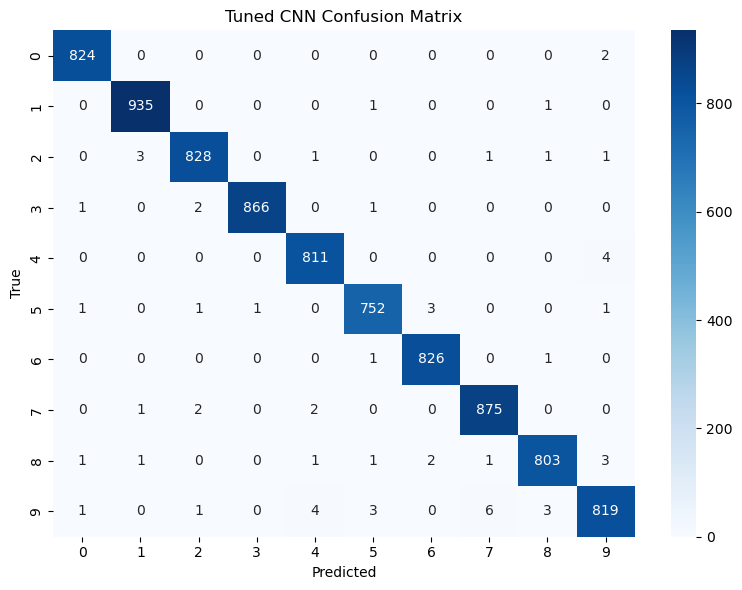

In [34]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned CNN Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### 3.3 Sample Predictions

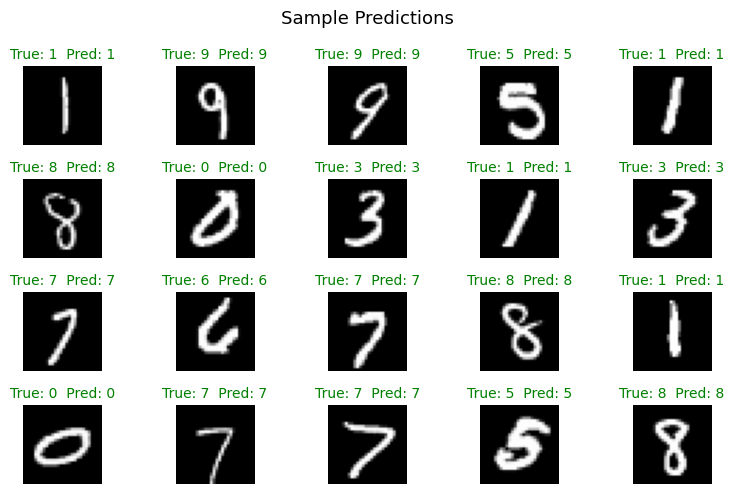

In [35]:
x_batch, y_batch = next(iter(dm.test_dataloader()))
sample_preds = cnn_model(x_batch.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(8, 5))
for i, ax in enumerate(axes.flatten()):
    img = x_batch[i].numpy().reshape(28, 28)
    true = y_batch[i].item()
    pred = sample_preds[i].item()
    color = "green" if true == pred else "red"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true}  Pred: {pred}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

From our mini-batch of samples, the tuned CNN model predicted each digit correctly.

## 4. Conclusion
#### Suggestions for Improvement:
* Test even more hyperparameters
* Experiment with libraries that were made to be improvements on specific activation functions, loss, etc.
### Key Findings:
* From classification with Logistic Regression to Deep Learning, neural networks display an advantageous gap in performance.
* Tuning hyperparamaters was always beneficial for the neural networks.
* Final validation scores are:
    1. **Tuned CNN            - 0.9924**
    2. Base CNN             - 0.9885
    3. Tuned MLP            - 0.9776
    4. Base MLP             - 0.9744
    5. Log Regression       - 0.9146
* 🏆️ The best model is a tuned CNN model.